# E-Commerce Product Classifier — Hinglish Multi-Model Weighted Voting

**Pipeline:** Hinglish text → Normalize → Tokenize → BERT + LSTM + ML Ensemble → Weighted Soft Voting → Label + Confidence

```
Input (noisy Hinglish)
       ↓
  Normalizer  (informal spellings, code-mix)
       ↓
  BPE Tokenizer (TikTok-style)
       ↓
  ┌────────────┬──────────────┬──────────────┐
  │  BERT      │  BiLSTM      │  LR+RF+XGB   │
  │  (0.60)    │  (0.25)      │  (0.15)      │
  └─────┬──────┴──────┬───────┴──────┬───────┘
         └────────────┼──────────────┘
                Weighted Soft Vote
                       ↓
              Label + Confidence Score
```

In [11]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))
!pip install torch transformers tokenizers scikit-learn xgboost seaborn --quiet
print('Setup complete')

Setup complete



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Dataset — Hinglish Product Descriptions

In [12]:
from data.sample_data import get_dataframe, LABEL2ID, ID2LABEL
import pandas as pd

df = get_dataframe()
print(f'Total samples: {len(df)}')
print(df['label'].value_counts())
df.head(10)

Total samples: 265
label
clothing              15
jewellery             15
beauty                15
footwear              15
home_decor            15
home_furniture        15
mobile_accessories    15
food_supplies         15
sportswear            15
electronics           15
agriculture           15
garments              15
laptops               15
stationery            15
kitchen_appliances    15
watches               10
eyewear               10
hazardous             10
printers              10
Name: count, dtype: int64


,text,label
0,banarasi silk saree red border,clothing
1,saree cotton printed floral,clothing
2,kurta pajama set men festive,clothing
3,lehenga choli bridal heavy work,clothing
4,salwar kameez ladies cotton,clothing
5,dupatta silk embroidered,clothing
6,sherwani men wedding,clothing
7,kurti short printed women,clothing
8,palazzo pants ladies,clothing
9,anarkali suit heavy embroidery,clothing


## 2. Preprocessing — Normalizer

In [13]:
from preprocessing.normalizer import normalize

examples = [
    'saari cotton printedddd floral',
    'jwellery necklace kundan bridal',
    'mobail phone 5g android new best',
    'mehandi cone natural dark free offer',
]
for ex in examples:
    print(f'  Before: {ex}')
    print(f'  After : {normalize(ex)}')
    print()

  Before: saari cotton printedddd floral
  After : saree cotton printedd floral

  Before: jwellery necklace kundan bridal
  After : jewellery necklace kundan bridal

  Before: mobail phone 5g android new best
  After : mobile phone 5g android

  Before: mehandi cone natural dark free offer
  After : mehendi cone natural dark



## 3. BPE Tokenizer (TikTok-style)

In [14]:
from preprocessing.normalizer import normalize_batch
from preprocessing.tokenizer import BPETokenizer

texts_clean = normalize_batch(df['text'].tolist())
bpe = BPETokenizer(vocab_size=4000, save_path='bpe_tokenizer.json')
bpe.train(texts_clean)

sample = 'saree pin gold fancy'
print(f'Input  : {sample}')
print(f'Tokens : {bpe.encode(normalize(sample))}')

[BPE] Trained on 265 texts. Vocab size: 1419
Input  : saree pin gold fancy
Tokens : [151, 302, 149, 1192]


## 4. Train All Models

[Train] Device: cpu
[Augment] 265 → 876 samples (5x)
[Train] Train: 744 | Test: 132 | Classes: 19

[1/3] Training ML Ensemble...
[ML Ensemble] Trained on 744 samples
[ML Ensemble] Saved to ml_ensemble.joblib

  Accuracy  : 0.9091
  Precision : 0.9312
  Recall    : 0.9091
  F1 Score  : 0.9096

Classification Report:
                    precision    recall  f1-score   support

          clothing       1.00      1.00      1.00         9
         jewellery       1.00      0.88      0.93         8
            beauty       0.54      0.88      0.67         8
          footwear       0.88      1.00      0.93         7
        home_decor       0.86      1.00      0.92         6
    home_furniture       1.00      0.83      0.91         6
           eyewear       1.00      1.00      1.00         5
           watches       1.00      0.83      0.91         6
mobile_accessories       0.89      1.00      0.94         8
        sportswear       0.88      1.00      0.93         7
     food_supplies    

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3197.15it/s]
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[BERT] Epoch 1/8 | Loss: 2.8734 | Acc: 0.1398
[BERT] Epoch 2/8 | Loss: 2.4791 | Acc: 0.3777
[BERT] Epoch 3/8 | Loss: 1.9840 | Acc: 0.6062
[BERT] Epoch 4/8 | Loss: 1.5390 | Acc: 0.7755
[BERT] Epoch 5/8 | Loss: 1.2172 | Acc: 0.9099
[BERT] Epoch 6/8 | Loss: 0.9873 | Acc: 0.9610
[BERT] Epoch 7/8 | Loss: 0.8847 | Acc: 0.9758
[BERT] Epoch 8/8 | Loss: 0.8253 | Acc: 0.9879

  Accuracy  : 0.9091
  Precision : 0.9201
  Recall    : 0.9091
  F1 Score  : 0.9038

Classification Report:
                    precision    recall  f1-score   support

          clothing       1.00      1.00      1.00         9
         jewellery       1.00      1.00      1.00         8
            beauty       0.88      0.88      0.88         8
          footwear       1.00      1.00      1.00         7
        home_decor       1.00      1.00      1.00         6
    home_furniture       1.00      1.00      1.00         6
           eyewear       1.00      0.80      0.89         5
           watches       1.00      1.00   

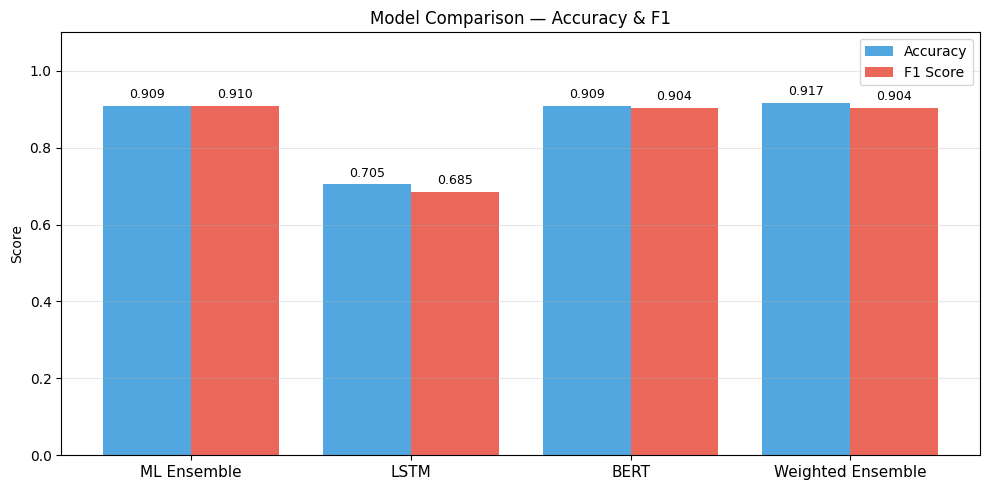

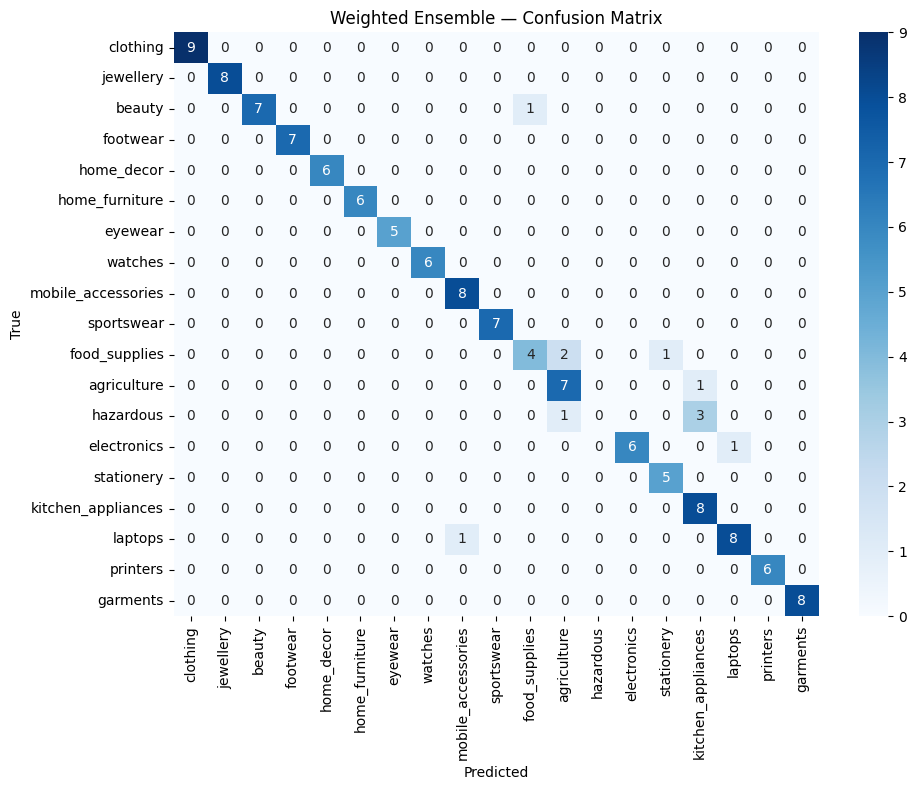


✅ Training complete.


In [15]:
from train import main
results = main()

## 4b. Clear Cache After Training

In [16]:
from utils.cache_cleaner import clean
clean()  # frees GPU VRAM, closes figures, runs GC, reloads module cache


[Cache] Before cleanup:

  RAM usage : 2798.1 MB
  sys.modules: 4554 loaded

[Cache] Removed 12 cached modules: ['data.sample_data', 'preprocessing.normalizer', 'preprocessing.tokenizer', 'data.augment', 'models.bert_classifier']...
[Cache] No GPU — skipping VRAM flush
[Cache] Closed 0 matplotlib figures
[Cache] GC collected 111196 objects | RAM: 2806 → 1830 MB

[Cache] After cleanup:

  RAM usage : 1829.9 MB
  sys.modules: 4542 loaded



## 5. Model Comparison Chart

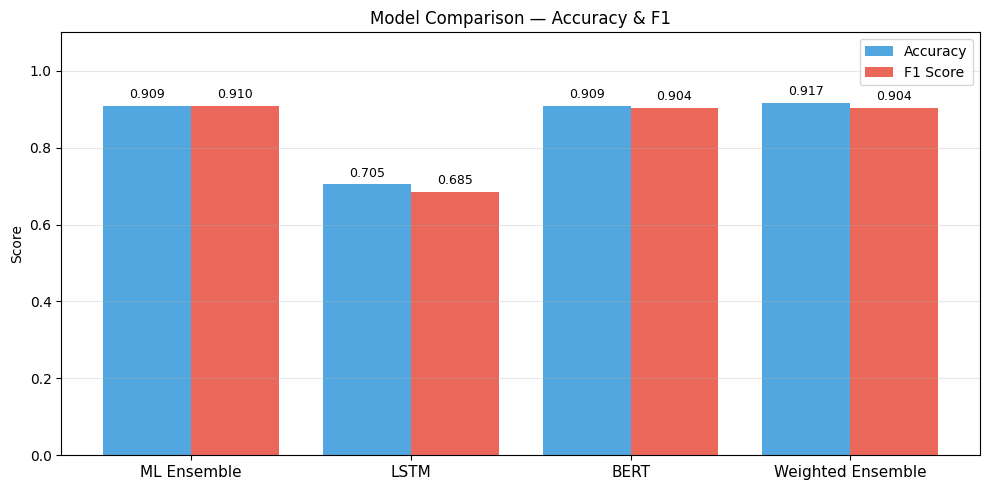

In [17]:
from evaluation.metrics import compare_models
compare_models(results)

## 6. Inference — Classify New Products

In [18]:
from predict import predict

test_cases = [
    'saree pin gold fancy',           # jewellery NOT clothing
    'banarasi silk saree red border',  # clothing
    'mobile phone 5g android',         # mobile_accessories
    'kajal black waterproof',          # beauty
    'diya clay diwali set',            # home_decor
    'jutti punjabi embroidered',       # footwear
    'sofa set 3 seater fabric',        # home_furniture
    'sunglasses polarized men',        # eyewear
    'watch men analog leather',        # watches
    'laptop 15 inch i5 8gb',           # laptops
    'mixer grinder 750w 3 jar',        # kitchen_appliances
    'basmati rice 5kg premium',        # food_supplies
    'seeds tomato hybrid packet',      # agriculture
    'acid hydrochloric lab grade',     # hazardous
    'notebook spiral a4 200 pages',    # stationery
    'printer inkjet color home',       # printers
    'jeans slim fit blue denim',       # garments
    'cricket bat junior size',         # sportswear
    'saari cotton printed',            # clothing (informal spelling)
    'jwellery necklace kundan',        # jewellery (misspelled)
]

results_inf = predict(test_cases)
for text, res in zip(test_cases, results_inf):
    bar = '█' * int(res['confidence'] * 20)
    print(f'{text:<42} → {res["label"]:<20} {bar} {res["confidence"]*100:.1f}%')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3643.94it/s]
BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


saree pin gold fancy                       → jewellery            █████████████████ 86.6%
banarasi silk saree red border             → clothing             ███████████████ 79.5%
mobile phone 5g android                    → mobile_accessories   ███████████ 57.4%
kajal black waterproof                     → beauty               █████████████ 69.6%
diya clay diwali set                       → home_decor           ████████ 40.3%
jutti punjabi embroidered                  → footwear             ███████████ 57.7%
sofa set 3 seater fabric                   → home_furniture       █████████████ 67.9%
sunglasses polarized men                   → eyewear              ████████████ 63.5%
watch men analog leather                   → watches              ██████████████ 75.0%
laptop 15 inch i5 8gb                      → laptops              █████████████████ 87.9%
mixer grinder 750w 3 jar                   → kitchen_appliances   ██████████████ 70.8%
basmati rice 5kg premium                   → food_su

## 7. Confusion Matrix

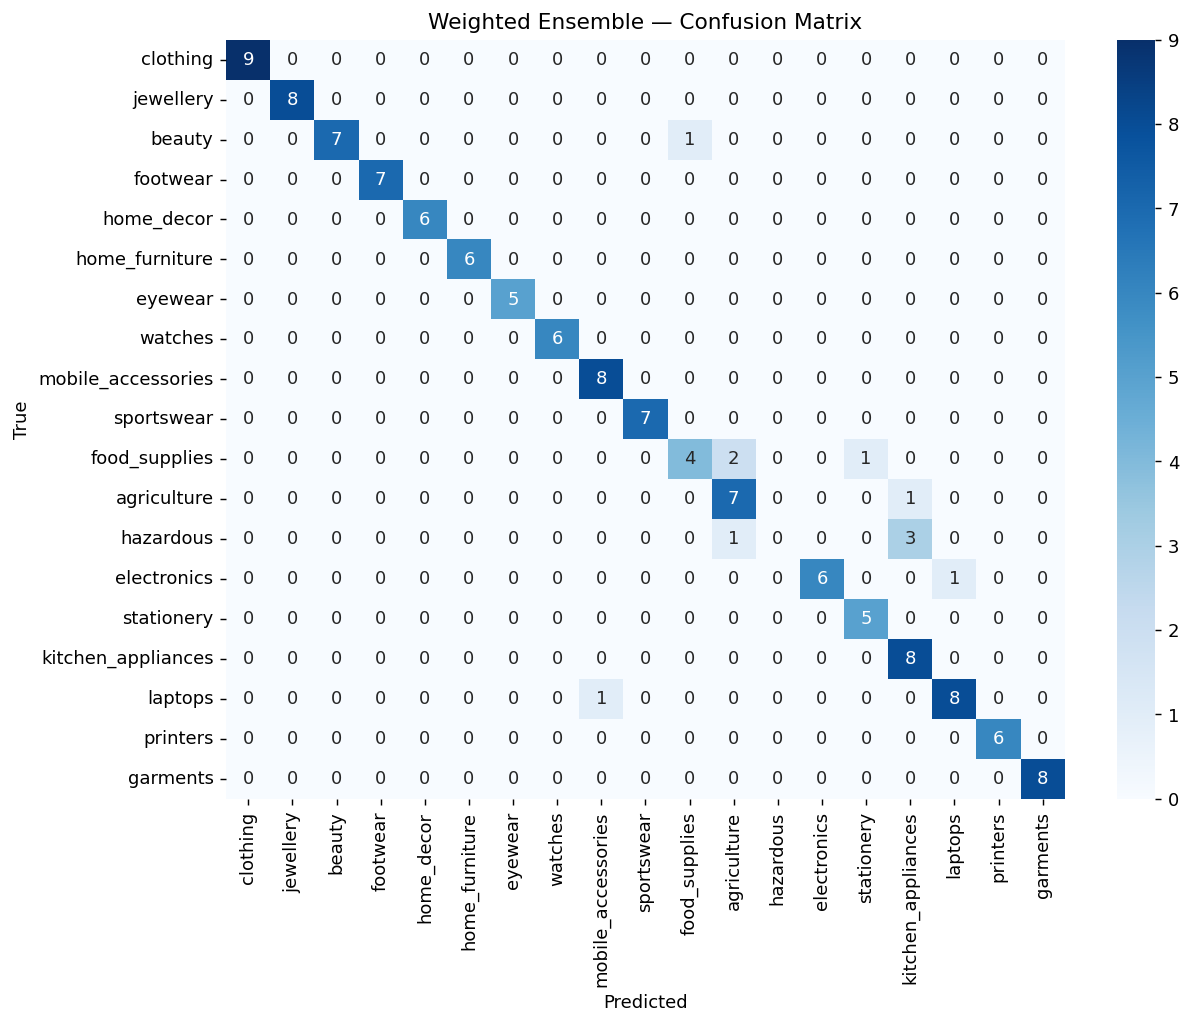

In [20]:
from IPython.display import Image
Image('confusion_matrix.png')

## 8. Weighted Voting — How It Works

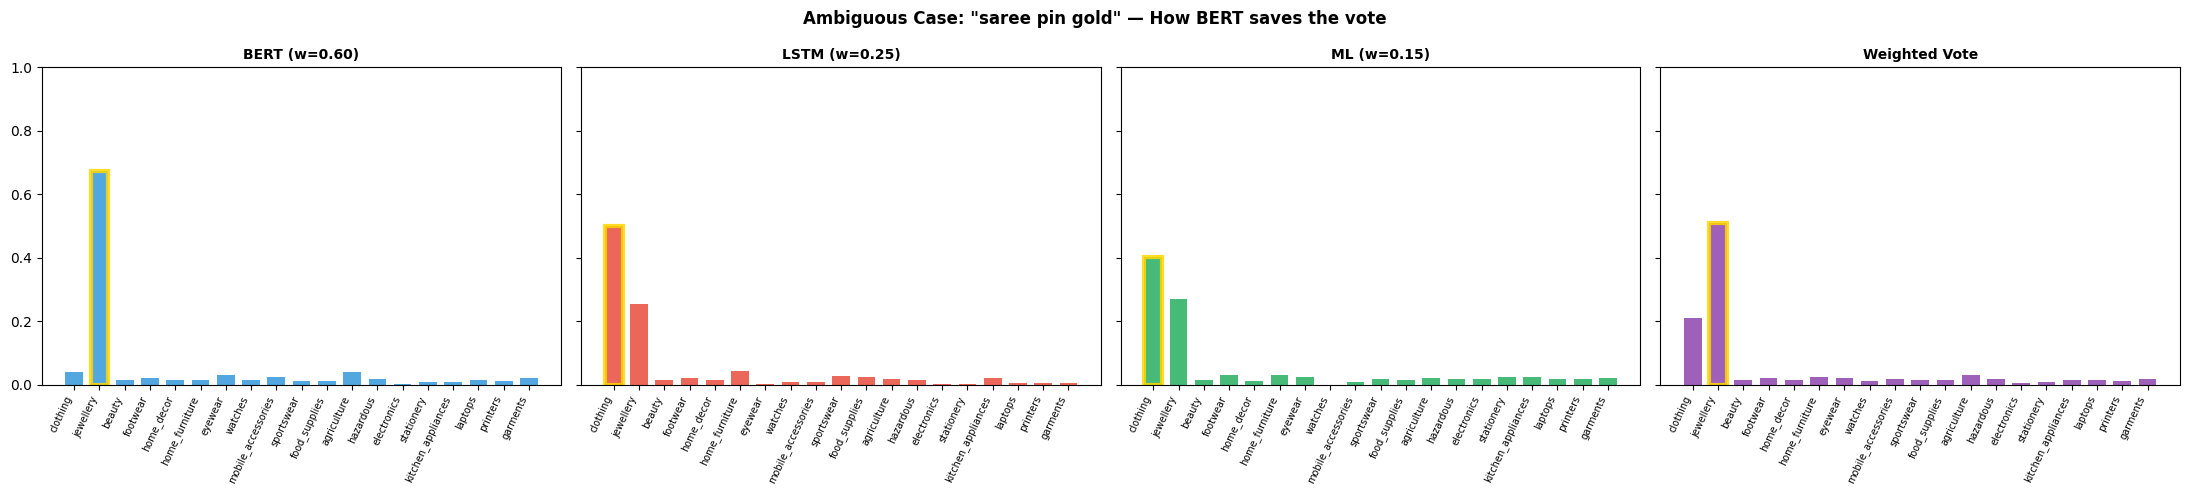

Final prediction: jewellery.upper() ✅


In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Hardcoded — no import dependency, always works
labels = [
    'clothing', 'jewellery', 'beauty', 'footwear', 'home_decor',
    'home_furniture', 'eyewear', 'watches', 'mobile_accessories', 'sportswear',
    'food_supplies', 'agriculture', 'hazardous', 'electronics', 'stationery',
    'kitchen_appliances', 'laptops', 'printers', 'garments'
]
n = len(labels)

def make_probs(clothing_score, jewellery_score):
    np.random.seed(None)
    p = np.abs(np.random.normal(0.02, 0.01, n))
    p[0] = clothing_score
    p[1] = jewellery_score
    return p / p.sum()

np.random.seed(42)
bert_p   = make_probs(0.05, 0.82)
lstm_p   = make_probs(0.55, 0.28)
ml_p     = make_probs(0.48, 0.32)
weighted = 0.60*bert_p + 0.25*lstm_p + 0.15*ml_p

x = np.arange(n)
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
fig.suptitle('Ambiguous Case: "saree pin gold" — How BERT saves the vote', fontweight='bold')

for ax, probs, title, color in zip(
    axes,
    [bert_p, lstm_p, ml_p, weighted],
    ['BERT (w=0.60)', 'LSTM (w=0.25)', 'ML (w=0.15)', 'Weighted Vote'],
    ['#3498db', '#e74c3c', '#27ae60', '#8e44ad']
):
    bars = ax.bar(x, probs, color=color, alpha=0.85, width=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=65, ha='right', fontsize=7)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1)
    pred_idx = int(probs.argmax())
    bars[pred_idx].set_edgecolor('gold')
    bars[pred_idx].set_linewidth(3)

plt.tight_layout()
plt.savefig('voting_visualization.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Final prediction: {labels[int(weighted.argmax())]}.upper() ✅')